In [2]:
import os
os.environ.pop("TF_USE_LEGACY_KERAS", None)


import librosa
%matplotlib inline
import matplotlib.pyplot as plt
import librosa.display
from IPython.display import Audio
import numpy as np
import tensorflow as tf
from matplotlib.pyplot import specgram
import pandas as pd
from sklearn.metrics import confusion_matrix
import IPython.display as ipd
import sys

data = pd.read_csv('../../data/featureEmodb.csv')

In [1]:
import numpy as np
import random

np.random.seed(42)
random.seed(42)

In [4]:
data

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530,-255.980286,105.676674,-42.180950,75.896423,-23.686800,10.384299,-17.101816,-5.522916,-3.057154,-10.192598,...,56.598065,0.013773,-0.044897,0.036112,-0.103853,0.014030,0.004264,1,2,16
531,-246.298492,91.399818,-25.200518,57.381245,-6.517654,19.359470,-4.424452,-3.416811,2.381373,-6.032308,...,56.940429,0.022640,0.051658,0.111283,0.034628,0.032623,-0.023948,1,7,16
532,-287.566315,88.560669,-21.810999,60.376926,-0.650359,19.902147,-0.450192,2.266046,3.220632,-6.157897,...,56.867307,0.064417,0.045792,-0.014448,0.036817,-0.002728,-0.039342,1,7,16
533,-329.608124,67.631531,-87.368507,64.361099,-49.395180,-1.466112,-20.686680,-10.990952,-6.811410,-28.455215,...,53.589258,0.004312,0.004346,-0.046711,-0.008183,-0.011669,0.014701,1,1,16


In [5]:
import joblib

# Load the saved scaler
scaler = joblib.load("../scaler.pkl")

# Load the saved model
gender_model = tf.keras.models.load_model("../gender_classification_model.h5")

W0000 00:00:1762244583.234218    7614 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [6]:
X_gender = data.iloc[:, :193].values
X_scaled = scaler.transform(X_gender)
gender_predictions = gender_model.predict(X_scaled)

17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


In [7]:
print(gender_predictions)

[[4.7407206e-03]
 [4.6157639e-04]
 [3.0386730e-03]
 [1.5244816e-03]
 [7.6849392e-04]
 [1.3095990e-03]
 [4.9879780e-04]
 [3.7963458e-04]
 [3.6571410e-01]
 [3.3532761e-03]
 [4.4729807e-03]
 [1.0930039e-03]
 [3.4315388e-03]
 [1.1107280e-03]
 [1.6056279e-03]
 [6.9866033e-04]
 [1.7894120e-03]
 [1.4085156e-03]
 [1.4026258e-03]
 [4.9669142e-03]
 [7.3762791e-04]
 [1.4017993e-03]
 [2.5455654e-03]
 [4.2543965e-04]
 [2.2492836e-04]
 [3.7402197e-04]
 [1.4532276e-03]
 [9.3619450e-04]
 [2.0258799e-03]
 [6.3483091e-04]
 [1.3890385e-03]
 [5.2728243e-03]
 [2.6253152e-03]
 [1.3338311e-03]
 [3.6826252e-03]
 [1.3467688e-03]
 [1.6858345e-03]
 [1.5898977e-03]
 [1.5722886e-03]
 [2.3024366e-03]
 [1.0618231e-03]
 [5.0643552e-03]
 [8.8569603e-04]
 [9.5791030e-01]
 [4.6573421e-03]
 [2.3879295e-03]
 [3.0233574e-03]
 [2.4481892e-04]
 [1.0407864e-03]
 [9.9979520e-01]
 [9.9941456e-01]
 [9.9919921e-01]
 [9.8543602e-01]
 [9.9929470e-01]
 [6.3582540e-01]
 [9.9987793e-01]
 [9.9837410e-01]
 [9.9931735e-01]
 [9.9904519e-0

In [8]:
male_rows = gender_predictions.flatten() < 0.5  # 0 for Male, 1 for Female

df = data[male_rows]

print(f"Filtered dataset contains {df.shape[0]} male samples.")

Filtered dataset contains 231 male samples.


In [9]:
df.shape

(231, 196)

In [10]:
df

,0,1,2,3,4,5,6,7,8,9,...,186,187,188,189,190,191,192,gender,emo,speaker
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966,0,6,3
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522,0,3,3
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692,0,1,3
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109,0,6,3
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003,0,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,-226.837311,142.118576,-28.414316,80.523026,1.455291,23.349869,0.228496,8.992689,-1.293387,-8.069052,...,55.246181,0.053525,0.008467,-0.028974,0.005422,-0.001764,0.008940,0,3,15
462,-230.787430,144.326324,-33.574013,81.690323,2.609222,19.189894,-1.268384,1.757590,-5.874588,-8.334718,...,54.868097,0.011599,0.028150,0.043454,-0.076144,-0.029873,-0.009483,0,3,15
463,-241.483597,86.334290,-79.313057,60.149220,-35.301773,10.070037,-36.825592,-1.482556,-10.556535,-27.002111,...,57.157892,0.006267,-0.022636,0.110237,0.038134,-0.014842,-0.012087,0,1,15
467,-225.952362,110.469078,-51.468727,59.868607,-30.434052,20.564268,-4.415425,-12.465252,-6.229944,-10.831050,...,53.073092,0.000368,0.015891,-0.086811,0.079181,0.026298,-0.022507,1,3,16


In [11]:
data.iloc[:,-3] == 0 #male

0       True
1       True
2       True
3       True
4       True
       ...  
530    False
531    False
532    False
533    False
534    False
Name: gender, Length: 535, dtype: bool

In [12]:
X_speaker = df.iloc[:, -1].copy()
X = df.iloc[:, :-3].copy()
y = df.iloc[:,-2].copy()

In [13]:
X

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-290.069550,120.892410,-44.022133,59.493820,-25.234184,24.166288,-20.102554,-3.104467,-3.912210,-8.433292,...,14.751010,17.490223,16.878034,56.398769,0.009679,0.012519,-0.031646,0.024728,0.007912,0.001966
1,-274.512543,137.867325,-33.016861,49.305836,-7.529972,15.471715,-6.811347,-7.069037,-8.804790,-1.528063,...,14.512919,17.550766,19.076122,53.806400,-0.001984,0.006133,-0.084608,0.109369,-0.025859,-0.003522
2,-225.866470,94.075874,-72.961555,41.311485,-27.577299,12.030844,-14.943604,-8.053857,-11.431667,-10.043902,...,16.131910,18.237524,19.299087,54.852081,0.001015,-0.006297,-0.033966,-0.076824,0.011315,-0.001692
3,-273.849060,98.794968,-36.564865,36.316208,-22.404598,18.368185,-12.455775,-1.077722,-12.487121,-17.107168,...,15.816742,17.617843,17.377833,58.313221,0.039030,-0.017753,-0.081100,-0.049775,0.015536,-0.007109
4,-252.887863,149.398911,-24.717367,45.297226,-0.930259,5.930630,0.473345,-0.681704,-12.864426,-9.714954,...,14.601713,14.795569,19.625183,51.336941,0.008184,-0.018455,-0.020061,-0.058433,0.009487,0.034003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,-226.837311,142.118576,-28.414316,80.523026,1.455291,23.349869,0.228496,8.992689,-1.293387,-8.069052,...,14.510448,16.331833,19.702384,55.246181,0.053525,0.008467,-0.028974,0.005422,-0.001764,0.008940
462,-230.787430,144.326324,-33.574013,81.690323,2.609222,19.189894,-1.268384,1.757590,-5.874588,-8.334718,...,14.435822,15.998726,21.182246,54.868097,0.011599,0.028150,0.043454,-0.076144,-0.029873,-0.009483
463,-241.483597,86.334290,-79.313057,60.149220,-35.301773,10.070037,-36.825592,-1.482556,-10.556535,-27.002111,...,17.573553,19.802764,18.747541,57.157892,0.006267,-0.022636,0.110237,0.038134,-0.014842,-0.012087
467,-225.952362,110.469078,-51.468727,59.868607,-30.434052,20.564268,-4.415425,-12.465252,-6.229944,-10.831050,...,14.993037,16.806884,20.170647,53.073092,0.000368,0.015891,-0.086811,0.079181,0.026298,-0.022507


In [14]:
y

0      6
1      3
2      1
3      6
4      3
      ..
461    3
462    3
463    1
467    3
471    4
Name: emo, Length: 231, dtype: int64

In [15]:
X_speaker

0       3
1       3
2       3
3       3
4       3
       ..
461    15
462    15
463    15
467    16
471    16
Name: speaker, Length: 231, dtype: int64

In [16]:
X.shape, y.shape

((231, 193), (231,))

In [17]:
from sklearn.utils import shuffle

X, y, X_speaker = shuffle(X, y, X_speaker, random_state=42)

In [18]:
from keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
y1 = to_categorical(lb.fit_transform(y))

In [19]:
y1

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 1., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]], shape=(231, 7))

In [20]:
X.shape, y1.shape

((231, 193), (231, 7))

In [21]:
X2_speaker = X_speaker.copy().to_numpy()
X2=X.copy().to_numpy()
y2=y.copy().to_numpy()

In [22]:
X2.shape, X2_speaker.shape, y2.shape

((231, 193), (231,), (231,))

In [23]:
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from matplotlib.pyplot import specgram
import keras

from keras.preprocessing import sequence
from keras.models import Sequential
from keras.layers import Dense, Embedding, Activation
from keras.layers import LSTM

from keras.utils import to_categorical
from keras.layers import Input, Flatten, Dropout#, Activation
from keras.layers import Conv1D, MaxPooling1D, AveragePooling1D
from keras.models import Model
from keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix
from keras.layers import BatchNormalization

def model1(input_shape1):
    model = Sequential()

    model.add(Conv1D(256, 5,padding='same',
                     input_shape=(input_shape1,1)))
    model.add(BatchNormalization())
    model.add(Activation('relu'))


    model.add(Conv1D(256, 5,padding='same'))
    model.add(Activation('relu'))
    model.add(Dropout(0.1))

    model.add(BatchNormalization())

    model.add(MaxPooling1D(pool_size=(8)))
    model.add(Conv1D(256, 5,padding='same',))

    model.add(Activation('relu'))

    model.add(Conv1D(128, 5,padding='same',))
    model.add(Activation('relu'))
    model.add(Conv1D(128, 5,padding='same',))
    model.add(BatchNormalization())

    model.add(Activation('relu'))
    model.add(Dropout(0.2))

    model.add(Flatten())
    model.add(Dropout(0.2))
    model.add(Dense(7))
    model.add(BatchNormalization())
    model.add(Activation('softmax'))

    return model

In [24]:
import random, numpy as np
from keras import optimizers
kfold=5
def create_index(kfold, size):
    a = []
    for i in range(size):
        a.append(i)
    random.shuffle(a)
    arr = np.array(a)
    return arr.reshape(kfold, size//kfold)

In [25]:
X3=pd.DataFrame(X2)
X3

,0,1,2,3,4,5,6,7,8,9,...,183,184,185,186,187,188,189,190,191,192
0,-208.910248,125.349022,-48.216434,65.728065,-13.270079,25.278214,-16.683043,-1.313547,-10.103478,-15.045475,...,14.607237,16.906701,18.612986,57.840269,-0.007218,-0.022044,-0.064596,-0.011514,-0.003945,0.008396
1,-222.871460,141.330719,-18.279402,50.753983,-8.829011,43.278927,8.627772,4.493885,-10.757927,-11.156906,...,14.554454,16.258762,16.818926,53.553669,-0.018205,0.013022,-0.106262,0.044568,-0.033829,-0.020718
2,-297.756805,101.250778,-27.316051,37.142166,-9.808082,11.987041,-14.529042,-5.449854,-6.861272,-8.398640,...,15.312169,16.332211,18.195445,55.404335,-0.055662,0.046828,-0.049820,-0.093621,0.035203,-0.001573
3,-227.276489,117.560974,-71.827011,53.567783,-26.829647,-19.638556,-20.023067,1.306535,-32.439835,-14.818504,...,16.893183,18.241810,22.953684,57.007772,-0.029548,0.002693,0.061653,0.048098,-0.008257,0.011674
4,-251.700806,108.045067,-32.954029,56.045170,-18.849281,17.657915,-19.965820,-2.117244,-7.571694,-16.578705,...,16.280043,16.811897,16.726842,56.870287,-0.004876,-0.009968,-0.023945,0.013597,-0.000006,0.007349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,-221.299622,111.730133,-45.615910,43.802586,-31.535126,15.036695,-10.744883,-2.640197,-21.425074,-15.949928,...,16.498704,17.477927,18.143632,57.061680,0.009313,0.031640,-0.029664,0.010529,0.007420,-0.013430
227,-224.773209,103.399918,-48.181816,56.513786,-31.591372,16.865063,-23.058949,-4.456352,-10.293122,-22.141642,...,16.457777,16.969962,17.043288,57.630084,0.019240,0.003299,-0.004990,-0.017173,-0.019096,-0.005716
228,-313.725433,158.027695,-20.540934,52.245914,-6.385612,10.219404,13.875411,6.663727,-11.028713,-9.581209,...,15.705104,15.735247,20.262013,51.754496,-0.048010,-0.025778,0.055476,-0.118440,-0.015134,-0.018048
229,-232.295563,111.404900,-39.206280,50.869785,-14.307878,15.146712,-6.797171,-2.677145,-8.112752,-13.977810,...,15.202279,17.130587,18.996226,56.799487,-0.006414,-0.006828,-0.045594,-0.005368,-0.016053,0.014134


In [26]:
X3_speaker = pd.DataFrame(X2_speaker)
X3_speaker

,0
0,15
1,10
2,3
3,12
4,3
...,...
226,11
227,3
228,11
229,15


In [27]:
speakers = X_speaker.unique()
speakers

array([15, 10,  3, 12, 11, 16])

In [28]:
X3_col = X3_speaker.rename(columns={0: 'speaker'})
X3_col

,speaker
0,15
1,10
2,3
3,12
4,3
...,...
226,11
227,3
228,11
229,15


In [29]:
X_combined = pd.concat([X3, X3_col], axis=1)
X_combined

,0,1,2,3,4,5,6,7,8,9,...,184,185,186,187,188,189,190,191,192,speaker
0,-208.910248,125.349022,-48.216434,65.728065,-13.270079,25.278214,-16.683043,-1.313547,-10.103478,-15.045475,...,16.906701,18.612986,57.840269,-0.007218,-0.022044,-0.064596,-0.011514,-0.003945,0.008396,15
1,-222.871460,141.330719,-18.279402,50.753983,-8.829011,43.278927,8.627772,4.493885,-10.757927,-11.156906,...,16.258762,16.818926,53.553669,-0.018205,0.013022,-0.106262,0.044568,-0.033829,-0.020718,10
2,-297.756805,101.250778,-27.316051,37.142166,-9.808082,11.987041,-14.529042,-5.449854,-6.861272,-8.398640,...,16.332211,18.195445,55.404335,-0.055662,0.046828,-0.049820,-0.093621,0.035203,-0.001573,3
3,-227.276489,117.560974,-71.827011,53.567783,-26.829647,-19.638556,-20.023067,1.306535,-32.439835,-14.818504,...,18.241810,22.953684,57.007772,-0.029548,0.002693,0.061653,0.048098,-0.008257,0.011674,12
4,-251.700806,108.045067,-32.954029,56.045170,-18.849281,17.657915,-19.965820,-2.117244,-7.571694,-16.578705,...,16.811897,16.726842,56.870287,-0.004876,-0.009968,-0.023945,0.013597,-0.000006,0.007349,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,-221.299622,111.730133,-45.615910,43.802586,-31.535126,15.036695,-10.744883,-2.640197,-21.425074,-15.949928,...,17.477927,18.143632,57.061680,0.009313,0.031640,-0.029664,0.010529,0.007420,-0.013430,11
227,-224.773209,103.399918,-48.181816,56.513786,-31.591372,16.865063,-23.058949,-4.456352,-10.293122,-22.141642,...,16.969962,17.043288,57.630084,0.019240,0.003299,-0.004990,-0.017173,-0.019096,-0.005716,3
228,-313.725433,158.027695,-20.540934,52.245914,-6.385612,10.219404,13.875411,6.663727,-11.028713,-9.581209,...,15.735247,20.262013,51.754496,-0.048010,-0.025778,0.055476,-0.118440,-0.015134,-0.018048,11
229,-232.295563,111.404900,-39.206280,50.869785,-14.307878,15.146712,-6.797171,-2.677145,-8.112752,-13.977810,...,17.130587,18.996226,56.799487,-0.006414,-0.006828,-0.045594,-0.005368,-0.016053,0.014134,15


In [30]:
# Get top 5 speakers with the most data

speaker_counts = X_combined['speaker'].value_counts()
selected_speakers = speaker_counts.head(5).index.to_numpy()

print("Selected speakers:", selected_speakers)

Selected speakers: [15 11  3 10 12]


In [35]:
from skfeature.function.similarity_based import fisher_score
from keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler

hist=[]
scores=[]
totalsize=230
num_fea=125
a=create_index(kfold,totalsize)

for i in range (kfold):
    model_name = 'Model_'+str(i)
    savedir='emodb_speaker_male'
    model_path = os.path.join(savedir, (model_name+'.h5'))

    # Choose one test speaker from selected_speakers
    test_speaker = selected_speakers[i]

    # Use only speakers not in selected_speakers as training
    train_speakers = np.setdiff1d(speakers, [test_speaker])

    print(f"\n===== Fold {i} =====")
    print("Test speaker:", test_speaker)
    print("Train speakers:", train_speakers)

    # Get the indices for test and train
    train_indices = X_combined[X_combined['speaker'].isin(train_speakers)].index
    test_indices = X_combined[X_combined['speaker'] == test_speaker].index


    # Sanity check for overlaps
    overlap_indices = np.intersect1d(train_indices, test_indices)
    if len(overlap_indices) > 0:
        print(f"Overlap found in fold {i}! Overlapping indices: {overlap_indices}")
    else:
        print(f"No overlap in fold {i}.")

    
    # Prepare training and testing sets
    X_train = X_combined.drop(columns=['speaker']).iloc[train_indices, :]
    y_train = y1[train_indices, :]
    y_train_fs = y.iloc[train_indices].to_numpy().ravel()

    X_test = X_combined.drop(columns=['speaker']).iloc[test_indices, :]
    y_test = y1[test_indices, :]


    # Scale separately
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Fisher score feature selection (on training data only)
    score = fisher_score.fisher_score(X_train_scaled, y_train_fs)
    sorted_indices = np.argsort(score)[::-1]
    fs_indices = sorted_indices[:num_fea]

    print(f"Top {num_fea} features: {fs_indices[:10]} ...")
    
    # Select top features
    X_train_fs = X_train_scaled[:, fs_indices]
    X_test_fs = X_test_scaled[:, fs_indices]

    # CNN input shape adjustment
    x_traincnn = np.expand_dims(X_train_fs, axis=2)
    x_testcnn = np.expand_dims(X_test_fs, axis=2)

    m1= model1(x_traincnn.shape[1])
    opt = tf.keras.optimizers.RMSprop(learning_rate=0.00005, decay=1e-6)
    m1.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    early_stopping = EarlyStopping(monitor='val_accuracy', patience=700, restore_best_weights=True)

    # Train
    history = m1.fit(
        x_traincnn, y_train,
        batch_size=32, epochs=700,
        validation_data=(x_testcnn, y_test),
        callbacks=[early_stopping],
        verbose=1
    )
    hist.append(history)

    # Evaluate
    score_eval = m1.evaluate(x_testcnn, y_test, verbose=0)
    scores.append(score_eval)
    print(f"Fold {i} Test Accuracy: {score_eval[1]:.4f}")

    # Save data for reproducibility
    np.save(os.path.join(savedir, f"X_train_fold{i}.npy"), x_traincnn)
    np.save(os.path.join(savedir, f"y_train_fold{i}.npy"), y_train)

    np.save(os.path.join(savedir, f"X_test_fold{i}.npy"), x_testcnn)
    np.save(os.path.join(savedir, f"y_test_fold{i}.npy"), y_test)

    # Save model
    model_name = f"Model_{i}.h5"
    model_path = os.path.join(savedir, model_name)
    model_json = m1.to_json()
    with open(os.path.join(savedir, f"Model_{i}.json"), "w") as json_file:
        json_file.write(model_json)
    m1.save(model_path)


print("\n===== Cross-validation results =====")
for i, sc in enumerate(scores):
    print(f"Fold {i}: Loss={sc[0]:.4f}, Accuracy={sc[1]:.4f}")
print(f"\nAverage accuracy: {np.mean([s[1] for s in scores]):.4f}")


===== Fold 0 =====
Test speaker: 15
Train speakers: [ 3 10 11 12 16]
No overlap in fold 0.
Top 125 features: [114   1   0  15  11  21  13  82  73  22] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.2273 - loss: 1.9718 - val_accuracy: 0.2727 - val_loss: 1.9329
Epoch 2/700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.3636 - loss: 1.5915 - val_accuracy: 0.2909 - val_loss: 1.9231
Epoch 3/700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5341 - loss: 1.3242 - val_accuracy: 0.2545 - val_loss: 1.9217
Epoch 4/700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5909 - loss: 1.2521 - val_accuracy: 0.2364 - val_loss: 1.9210
Epoch 5/700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6477 - loss: 1.1694 - val_accuracy: 0.2000 - val_loss: 1.9238
Epoch 6/700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6648 - loss: 1.1464 - val_accuracy: 0.2000 - val_loss: 1.9229
Epoch 7/700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6875 - loss: 1.0986 - val_accuracy: 0.2000 - val_loss: 1.9281
Epoch 8/700
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7614 - loss: 0.9838 - val_accuracy: 0.2000 - val_loss: 1.9298
Epoc


===== Fold 1 =====
Test speaker: 11
Train speakers: [ 3 10 12 15 16]
No overlap in fold 1.
Top 125 features: [ 78   1   0  20   9  51   5 172  82  16] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.1538 - loss: 2.2484 - val_accuracy: 0.0833 - val_loss: 1.9589
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3641 - loss: 1.6389 - val_accuracy: 0.1389 - val_loss: 1.9473
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4513 - loss: 1.4648 - val_accuracy: 0.1667 - val_loss: 1.9459
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5846 - loss: 1.3436 - val_accuracy: 0.1111 - val_loss: 1.9500
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5436 - loss: 1.2803 - val_accuracy: 0.0833 - val_loss: 1.9617
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6462 - loss: 1.2443 - val_accuracy: 0.1389 - val_loss: 1.9687
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6513 - loss: 1.1780 - val_accuracy: 0.1667 - val_loss: 1.9762
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6872 - loss: 1.1475 - val_accuracy: 0.1111 - val_loss: 1.9773
Epoc

Fold 3 Test Accuracy: 0.7500

===== Fold 4 =====
Test speaker: 12
Train speakers: [ 3 10 11 15 16]
No overlap in fold 4.
Top 125 features: [ 93   1   0  15  14  25   4 178 111  20] ...
Epoch 1/700


/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.1939 - loss: 1.9916 - val_accuracy: 0.2000 - val_loss: 1.9305
Epoch 2/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3929 - loss: 1.5718 - val_accuracy: 0.1143 - val_loss: 1.9563
Epoch 3/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5510 - loss: 1.3394 - val_accuracy: 0.1143 - val_loss: 1.9797
Epoch 4/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6122 - loss: 1.2307 - val_accuracy: 0.1143 - val_loss: 2.0008
Epoch 5/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6939 - loss: 1.1579 - val_accuracy: 0.1143 - val_loss: 2.0162
Epoch 6/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6939 - loss: 1.0952 - val_accuracy: 0.1143 - val_loss: 2.0313
Epoch 7/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7143 - loss: 1.0565 - val_accuracy: 0.1143 - val_loss: 2.0448
Epoch 8/700
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7398 - loss: 1.0115 - val_accuracy: 0.1143 - val_loss: 2.0578
Epoc

Fold 4 Test Accuracy: 0.6286

===== Cross-validation results =====
Fold 0: Loss=1.3629, Accuracy=0.6727
Fold 1: Loss=1.2236, Accuracy=0.7455
Fold 2: Loss=1.3416, Accuracy=0.6458
Fold 3: Loss=1.3073, Accuracy=0.7500
Fold 4: Loss=1.3447, Accuracy=0.6286

Average accuracy: 0.6885


In [1]:
import numpy as np
import keras
from keras.models import model_from_json
from sklearn.metrics import confusion_matrix

savedir = 'emodb_speaker_male'
num_folds = 5 
opt = keras.optimizers.RMSprop(learning_rate=0.00001, decay=1e-6)

accuracies = []
conf_matrices = []

for i in range(num_folds):
    model_name = f"Model_{i}"

    with open(f"{savedir}/{model_name}.json", "r") as json_file:
        loaded_model = model_from_json(json_file.read())
    loaded_model.load_weights(f"{savedir}/{model_name}.h5")

    loaded_model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy'])

    X_test = np.load(f"{savedir}/X_test_fold{i}.npy")
    y_test = np.load(f"{savedir}/y_test_fold{i}.npy")

    score = loaded_model.evaluate(X_test, y_test, verbose=0)
    acc = score[1] * 100
    accuracies.append(acc)

    y_pred = loaded_model.predict(X_test, verbose=0)
    y_pred_labels = np.argmax(y_pred, axis=1)
    y_true_labels = np.argmax(y_test, axis=1)

    cm = confusion_matrix(y_true_labels, y_pred_labels)
    conf_matrices.append(cm)

    print(f"Fold {i}: Accuracy = {acc:.2f}%")

# array: (num_folds, num_classes, num_classes)
conf_matrices = np.array(conf_matrices)
mean_acc = np.mean(accuracies)

print("\nMean Accuracy: %.2f%%" % mean_acc)
print("SD Accuracy: %.2f" % np.std(accuracies))

n = num_folds
ci95 = 1.96 * (np.std(accuracies) / np.sqrt(n))
ci_low = mean_acc - ci95
ci_high = mean_acc + ci95
print(f"95% CI: [{ci_low:.2f}%, {ci_high:.2f}%]")

2025-11-10 15:09:35.539391: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-10 15:09:35.572600: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-10 15:09:36.242953: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/aruay/Desktop/gender-aware-SER-main/.venv/lib/python3.12/site-

Fold 0: Accuracy = 67.27%
Fold 1: Accuracy = 74.55%
Fold 2: Accuracy = 64.58%
Fold 3: Accuracy = 75.00%
Fold 4: Accuracy = 62.86%

Mean Accuracy: 68.85%
SD Accuracy: 5.04
95% CI: [64.44%, 73.27%]


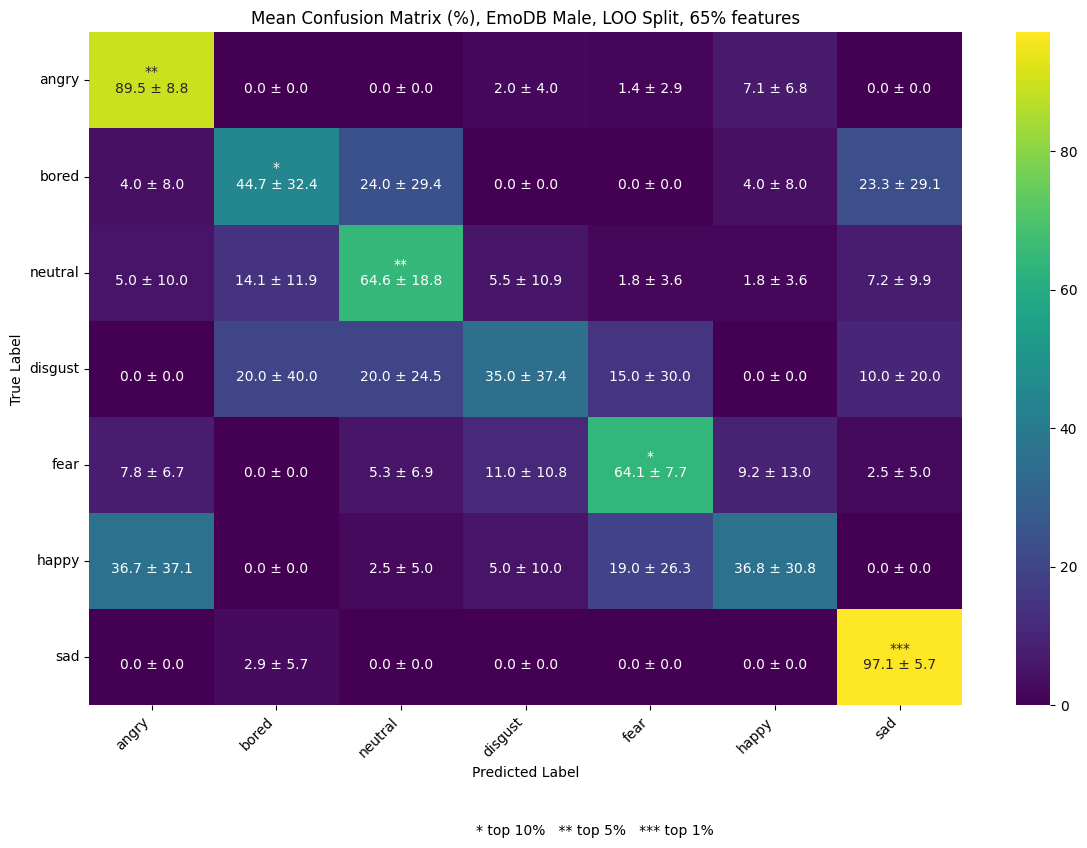

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrices_percent = conf_matrices / conf_matrices.sum(axis=2, keepdims=True) * 100

np.save('cm_emodb_speaker_male.npy', conf_matrices_percent)


mean_cm = np.mean(conf_matrices_percent, axis=0)
std_cm = np.std(conf_matrices_percent, axis=0)

# Compute percentile thresholds for annotation
flat_vals = mean_cm.flatten()
thr_90 = np.percentile(flat_vals, 90)
thr_95 = np.percentile(flat_vals, 95)
thr_99 = np.percentile(flat_vals, 99)

# Create annotation labels with significance symbols
labels = np.empty(mean_cm.shape, dtype=object)
for i in range(mean_cm.shape[0]):
    for j in range(mean_cm.shape[1]):
        val = mean_cm[i, j]
        symbol = ""
        if val >= thr_99:
            symbol = "***"
        elif val >= thr_95:
            symbol = "**"
        elif val >= thr_90:
            symbol = "*"
        labels[i, j] = f"{symbol}\n{val:.1f} ± {std_cm[i, j]:.1f}"

listik = ['angry', 'bored', 'neutral', 'disgust', 'fear', 'happy', 'sad']

# Plot
plt.figure(figsize=(12,8))
ax = sns.heatmap(mean_cm, annot=labels, fmt="", cmap="viridis", cbar=True)

ax.set_xticks(np.arange(len(listik)) + 0.5)
ax.set_yticks(np.arange(len(listik)) + 0.5)
ax.set_xticklabels(listik, rotation=45, ha="right")
ax.set_yticklabels(listik, rotation=0)

plt.title("Mean Confusion Matrix (%), EmoDB Male, LOO Split, 65% features")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.figtext(0.5, -0.05,
            "* top 10%   ** top 5%   *** top 1%",
            ha="center", fontsize=10)
plt.show()
